In [9]:
from astropy.io import fits
import numpy as np
import os

cwd = os.getcwd()
path = rf"{cwd}\Gaia_dr2_in100pc1.fits"
file  = fits.open(path)[1]




# DEBUGGING CORNER

In [35]:
file.columns

ColDefs(
    name = 'solution_id'; format = 'K'
    name = 'designation'; format = '28A'
    name = 'source_id'; format = 'K'
    name = 'random_index'; format = 'K'
    name = 'ref_epoch'; format = 'D'; unit = 'yr'
    name = 'ra'; format = 'D'; unit = 'deg'
    name = 'ra_error'; format = 'D'; unit = 'mas'
    name = 'dec'; format = 'D'; unit = 'deg'
    name = 'dec_error'; format = 'D'; unit = 'mas'
    name = 'parallax'; format = 'D'; unit = 'mas'
    name = 'parallax_error'; format = 'D'; unit = 'mas'
    name = 'parallax_over_error'; format = 'E'
    name = 'pmra'; format = 'D'; unit = 'mas.yr**-1'
    name = 'pmra_error'; format = 'D'; unit = 'mas.yr**-1'
    name = 'pmdec'; format = 'D'; unit = 'mas.yr**-1'
    name = 'pmdec_error'; format = 'D'; unit = 'mas.yr**-1'
    name = 'ra_dec_corr'; format = 'E'
    name = 'ra_parallax_corr'; format = 'E'
    name = 'ra_pmra_corr'; format = 'E'
    name = 'ra_pmdec_corr'; format = 'E'
    name = 'dec_parallax_corr'; format = 'E'
    na

Coordinate handling for Hyades

In [3]:
RA_hya = (4 + 30/60 + 27.4/3600)*15
# Convert RA from hours to degrees

DEC_hya = 16 + 46/60 + 43/3600
# Convert DEC with minutes and seconds to degrees with decimals instead

# SELECTING STARS

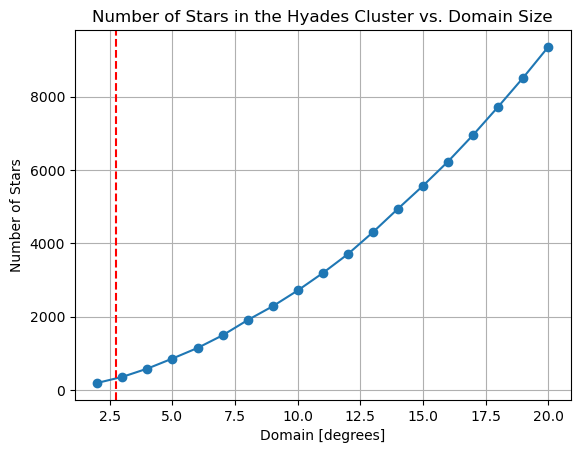

In [4]:
Delta = 5.5/2 # https://www.constellation-guide.com/hyades/

domain = np.arange(2,21,1)
N_stars = []
for D in domain:
    ra, dec = file.data['ra'], file.data['dec']
    mask_ra = (RA_hya-D <= ra) & (ra <= RA_hya+D ) # ra ∈ (RA_hya-D, RA_hya+D)
    mask_dec = (DEC_hya-D <= dec) & (dec <= DEC_hya+D ) # dec ∈ (DEC_hya-D, DEC_hya+D)
    filtered_data = file.data[mask_ra & mask_dec] 
    n_stars = len(filtered_data)
    N_stars.append(n_stars)

%matplotlib inline
import matplotlib.pyplot as plt

plt.plot(domain, N_stars, marker='o')
plt.axvline(x=Delta,  color='r', linestyle='--', label=f'Literary Value = {Delta} degrees')
plt.xlabel('Domain [degrees]')
plt.ylabel('Number of Stars')
plt.title('Number of Stars in the Hyades Cluster vs. Domain Size')
plt.grid()
plt.show()

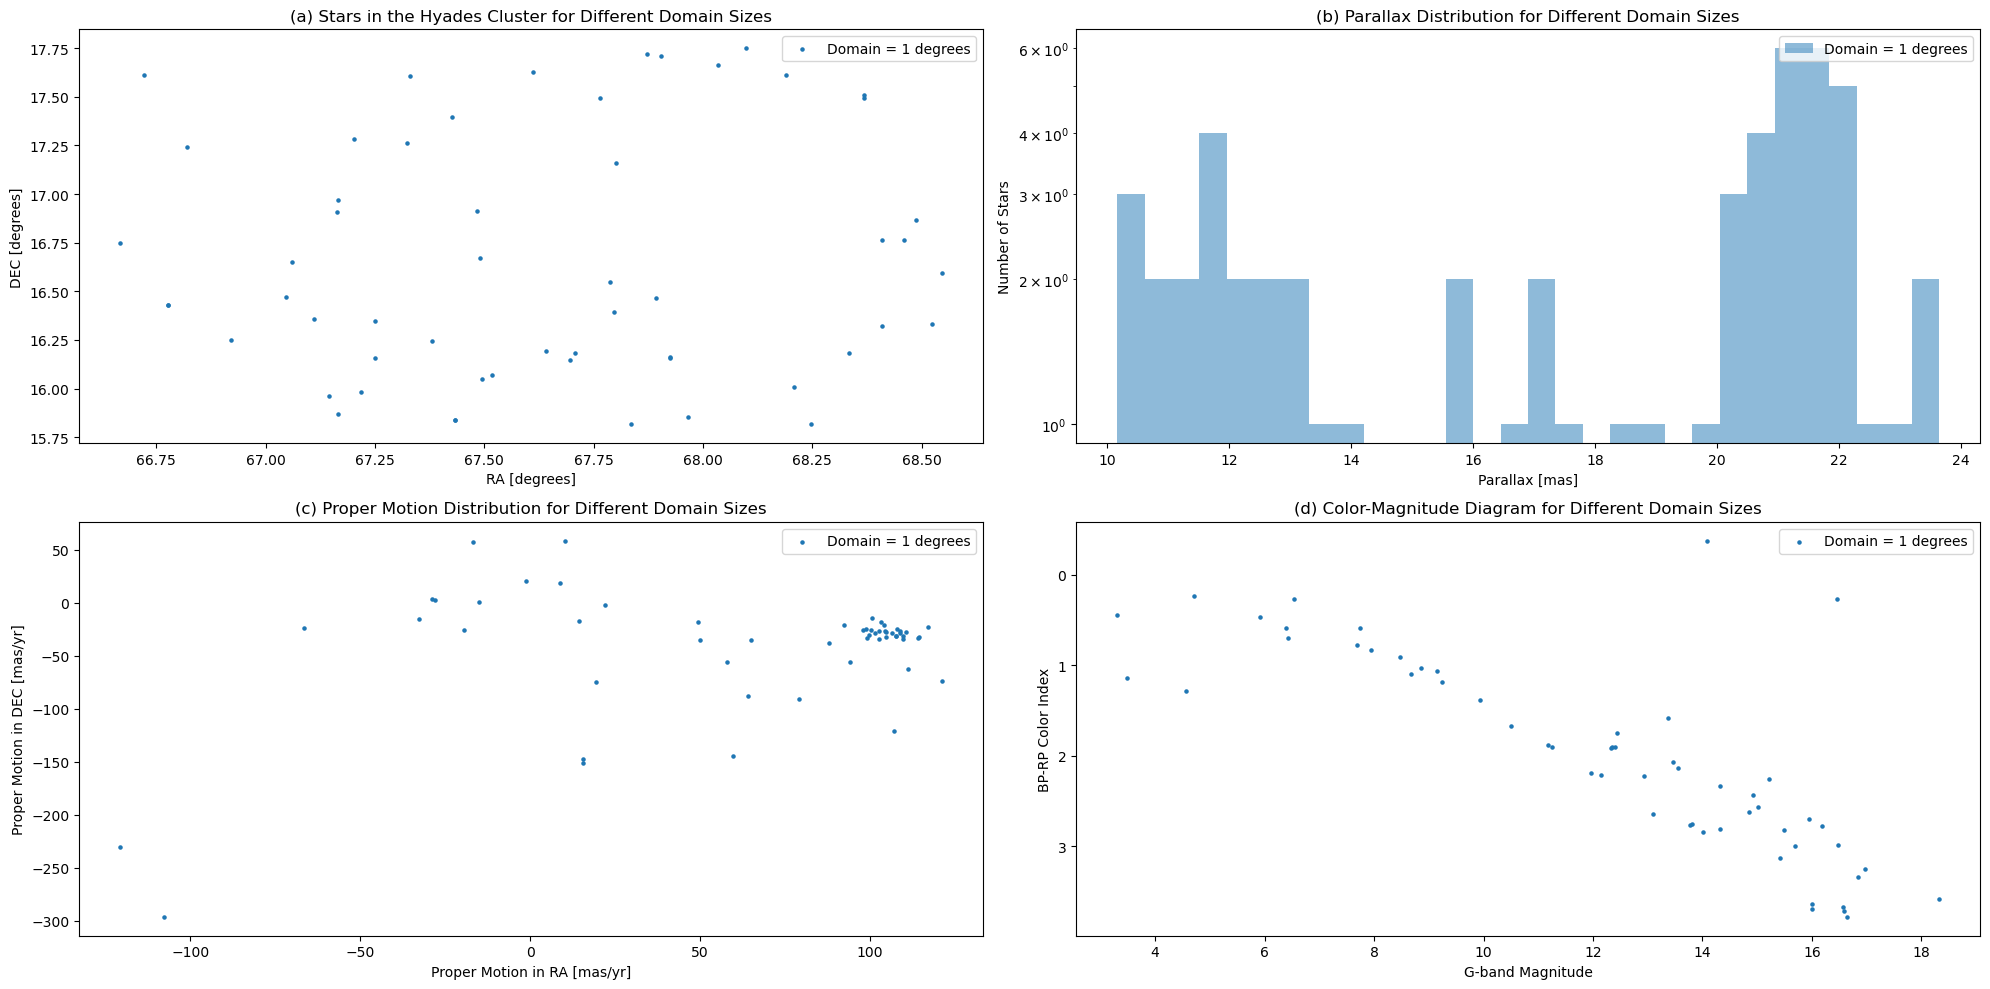

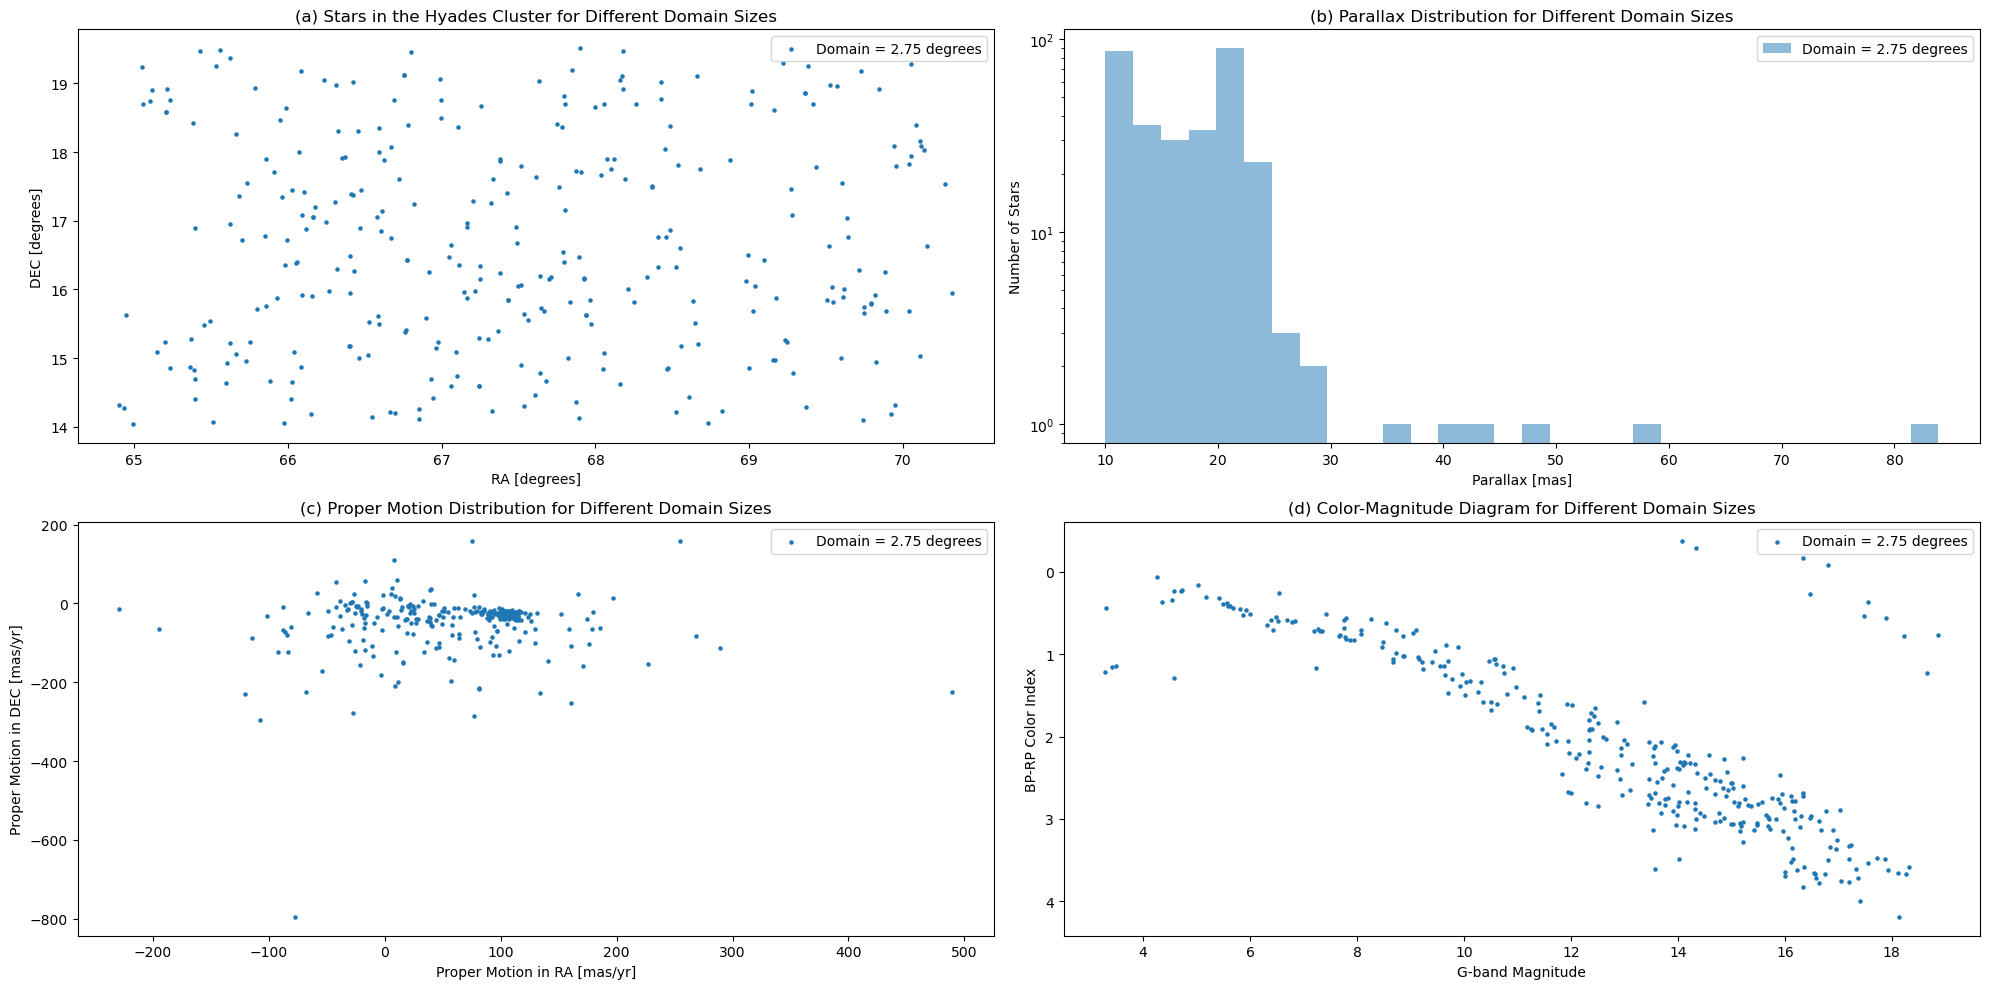

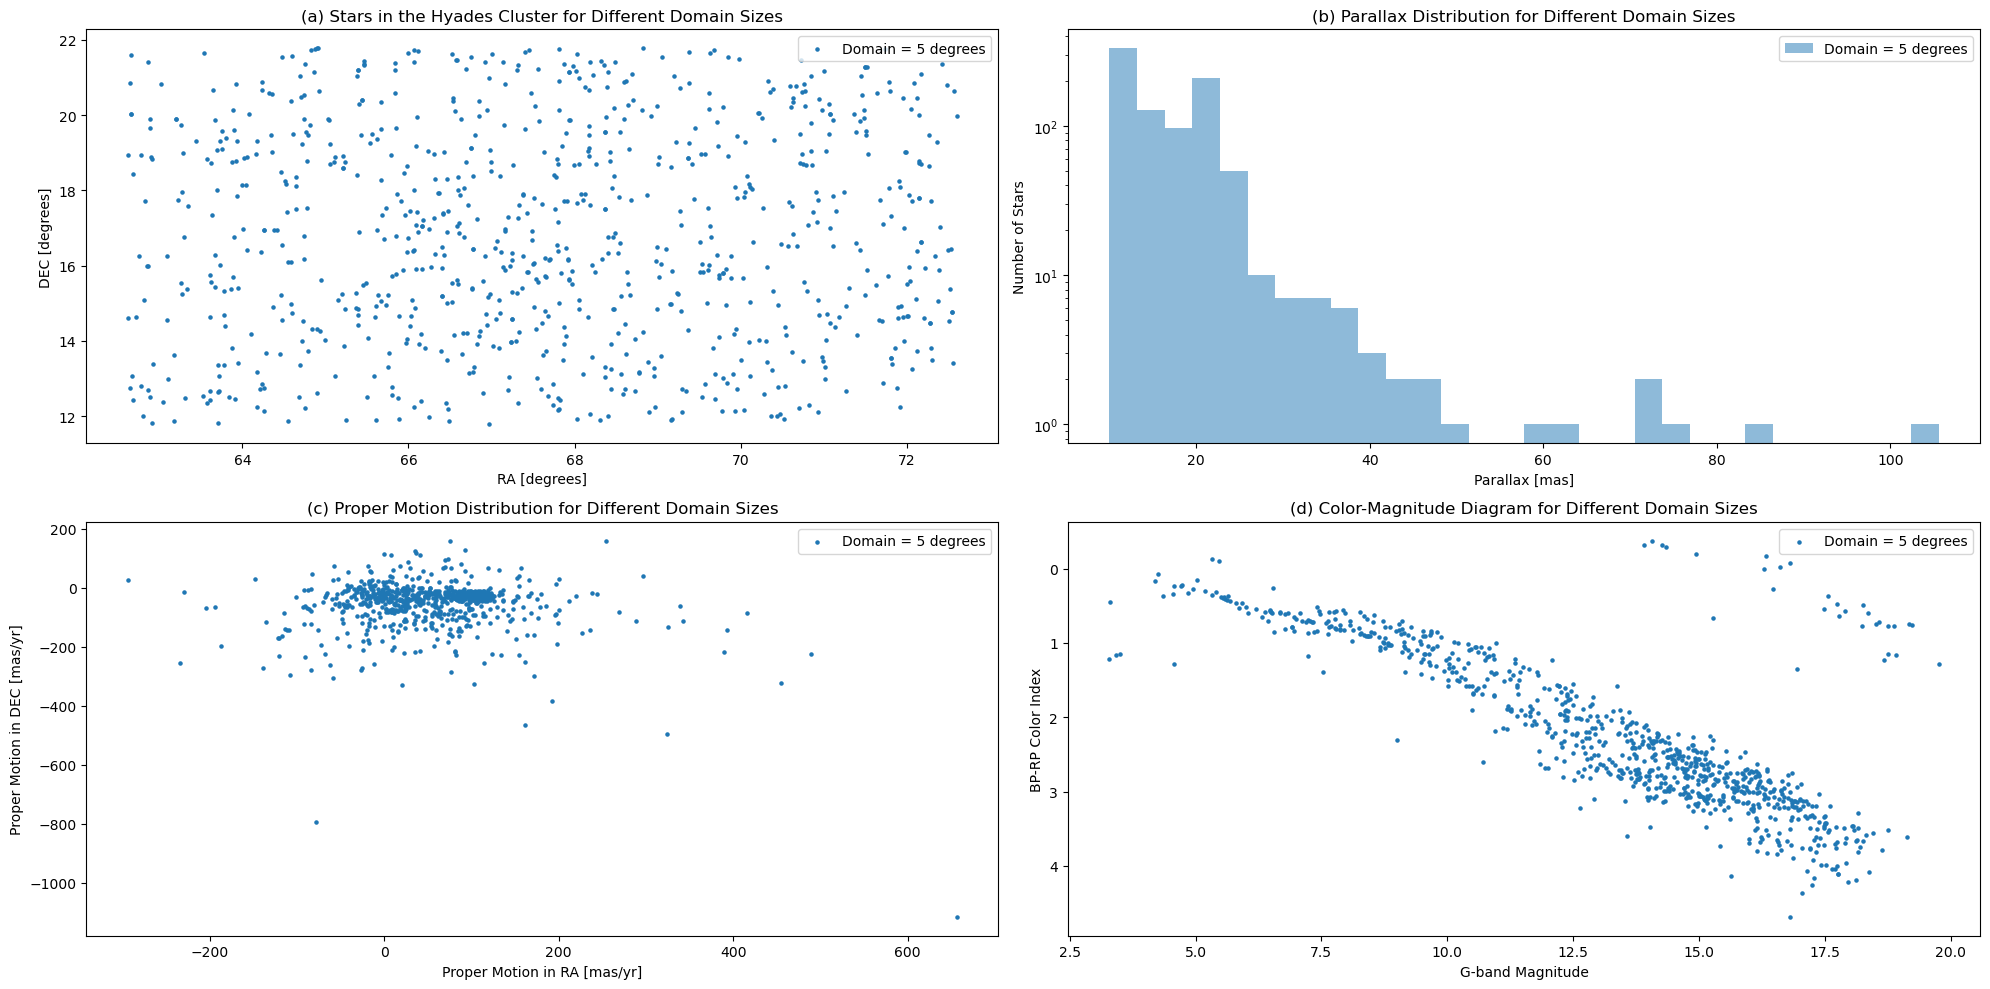

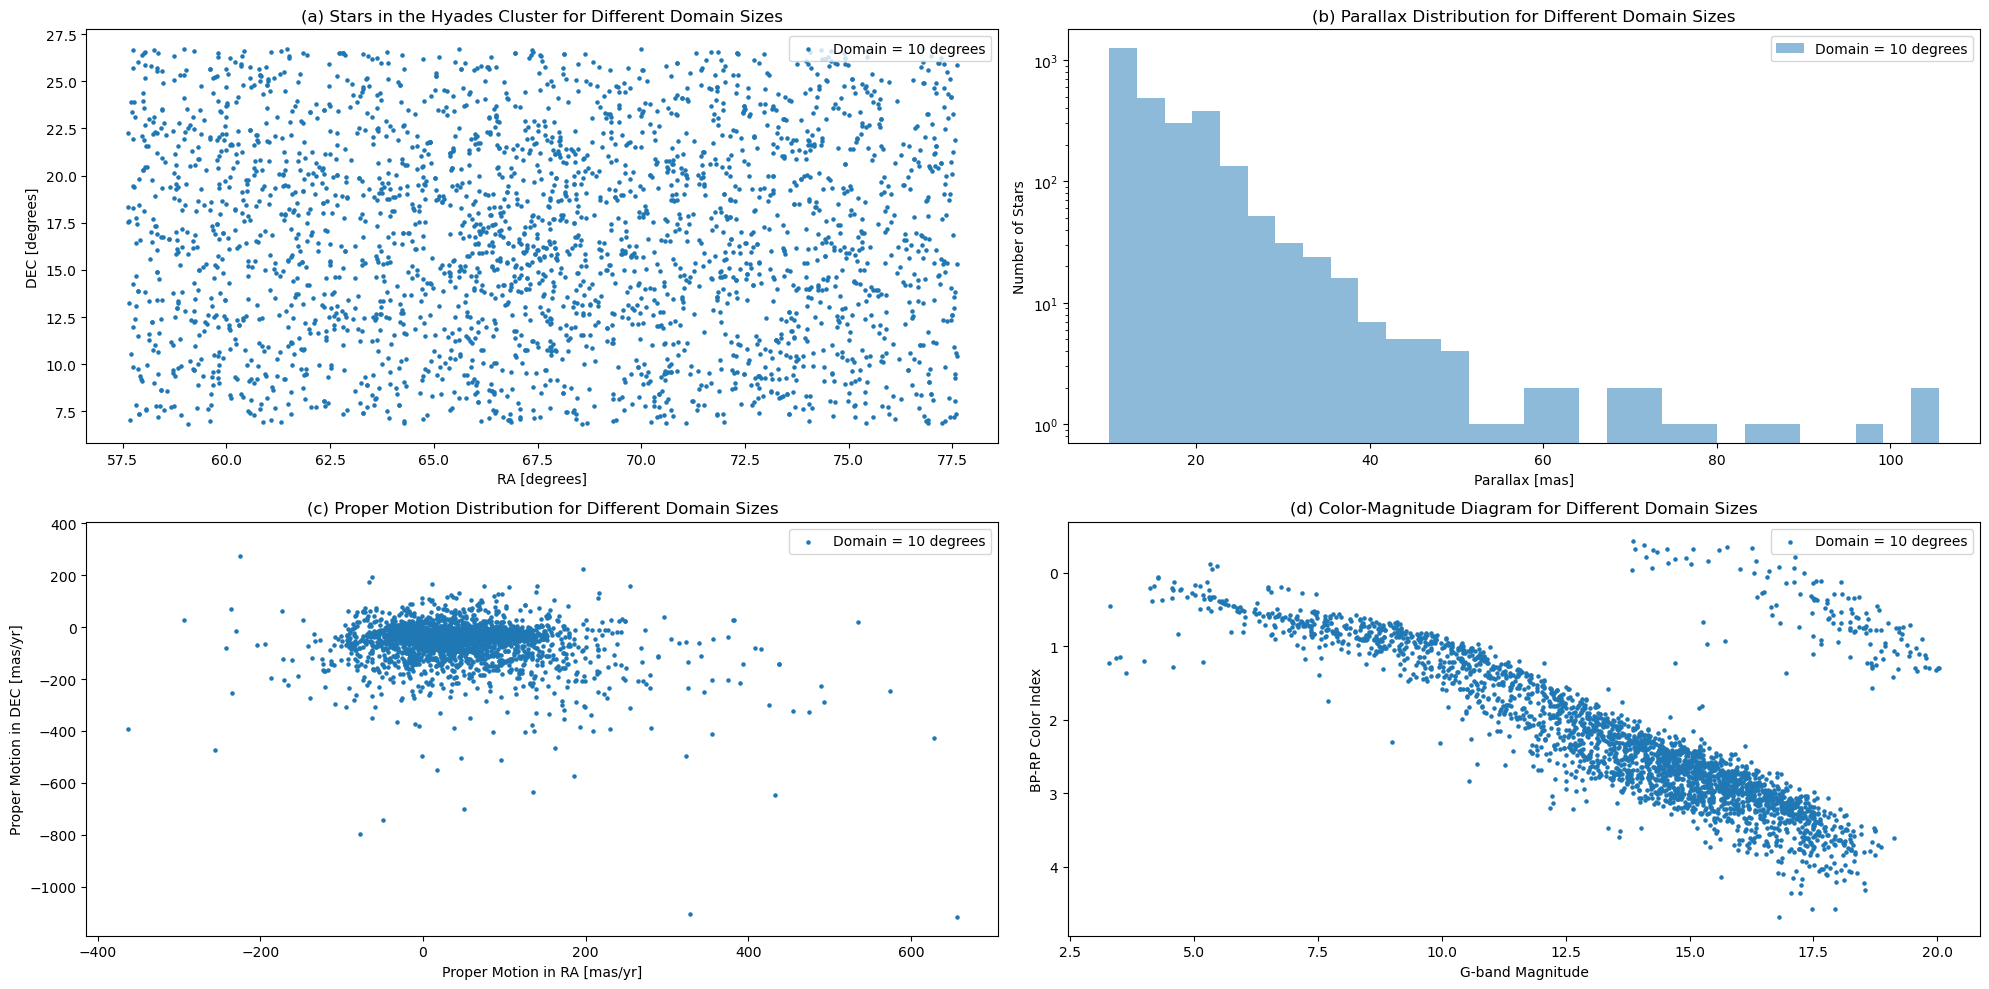

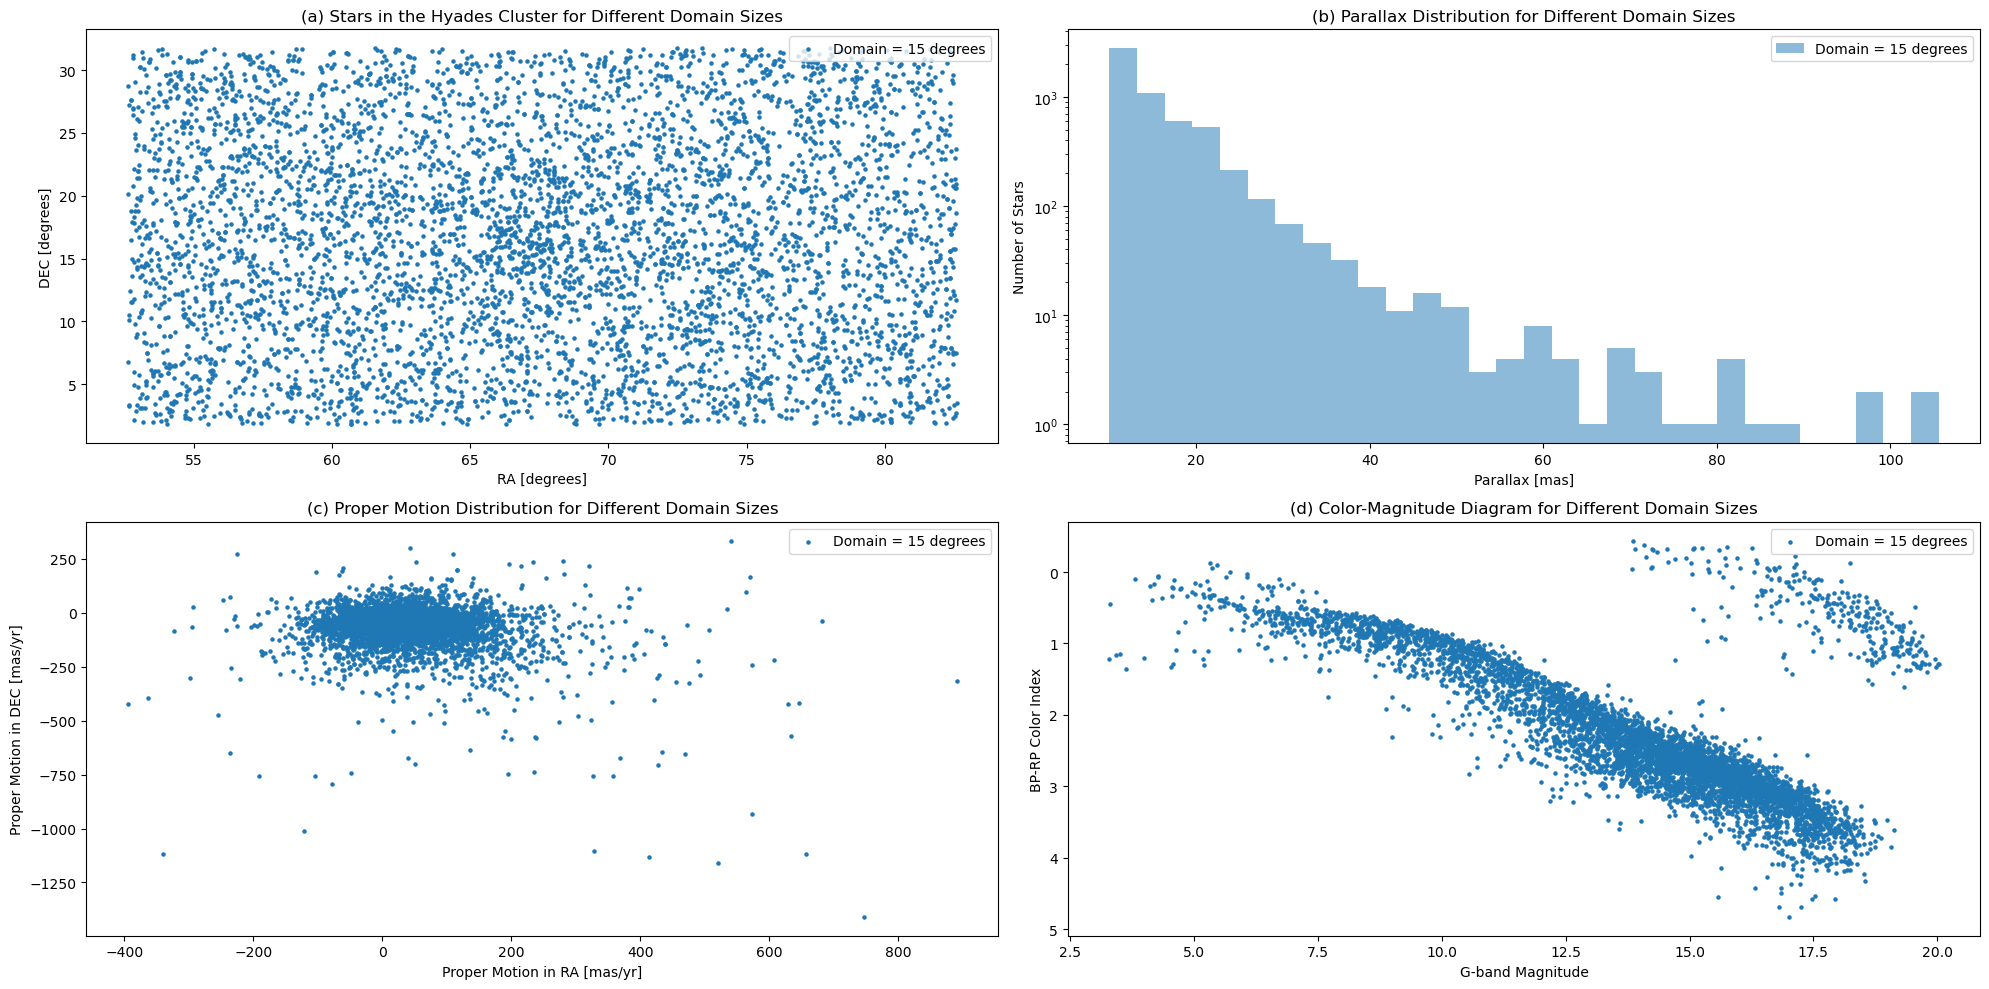

In [5]:


deltas = [1, 5.5/2,5, 10, 15] # Arbitrarily chosen (except 5.5/2, see previous cell)

for i, D in enumerate(deltas):
    fig2,((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2, figsize=(20,10))

    mask = (RA_hya-D <= file.data['ra']) & (file.data['ra'] <= RA_hya+D ) & (DEC_hya-D <= file.data['dec']) & (file.data['dec'] <= DEC_hya+D )
    data_D = file.data[mask]

    ax1.scatter(data_D['ra'], data_D['dec'], s=5, label=f'Domain = {D} degrees', zorder=-2*i)

    ax2.hist(data_D['parallax'], bins=30, alpha=0.5, label=f'Domain = {D} degrees', zorder=-2*i)

    ax3.scatter(data_D['PMRA'], data_D['PMDEC'], s=5, label=f'Domain = {D} degrees', zorder=-2*i)

    ax4.scatter(data_D['phot_g_mean_mag'], data_D['bp_rp'], s=5, label=f'Domain = {D} degrees', zorder=-2*i)

    ax1.set_xlabel('RA [degrees]')
    ax1.set_ylabel('DEC [degrees]')
    ax1.set_title('(a) Stars in the Hyades Cluster for Different Domain Sizes')
    ax1.legend(loc='upper right')


    ax2.set_xlabel('Parallax [mas]')
    ax2.set_ylabel('Number of Stars')
    ax2.set_yscale('log')
    ax2.set_title('(b) Parallax Distribution for Different Domain Sizes')
    ax2.legend(loc='upper right')

    ax3.set_xlabel('Proper Motion in RA [mas/yr]')
    ax3.set_ylabel('Proper Motion in DEC [mas/yr]')
    ax3.set_title('(c) Proper Motion Distribution for Different Domain Sizes')
    ax3.legend(loc='upper right')

    ax4.set_xlabel('G-band Magnitude')
    ax4.set_ylabel('BP-RP Color Index')
    ax4.set_title('(d) Color-Magnitude Diagram for Different Domain Sizes')
    ax4.invert_yaxis()  # Invert y-axis for magnitude
    ax4.legend(loc='upper right')

    plt.tight_layout()

plt.show()





# OPDRACHT 3

In [ ]:
# We can see that the data from 2.75 degrees is the most sharp (clear cutoffs)
parallax_bounds = (10,30) # [mas]
PMRA_bounds = (-100,350) # [mas/yr]
PMDEC_bounds = (-50,50)